# Part A — Data preparation 

In [1]:
# loading the dataset

import pandas as pd

fg = pd.read_csv('fear_greed_index.csv')
tr = pd.read_csv('historical_data.csv')

print("Fear/Greed Shape:", fg.shape)
print("Trader Data Shape:", tr.shape)

print("\nFear/Greed Columns:", fg.columns)
print("\nTrader Columns:", tr.columns)

Fear/Greed Shape: (2644, 4)
Trader Data Shape: (211224, 16)

Fear/Greed Columns: Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

Trader Columns: Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [2]:
# Missing values & duplicates 

print("\nMissing Values (FG):\n", fg.isnull().sum())
print("\nMissing Values (Trader):\n", tr.isnull().sum())

print("\nFG Duplicates:", fg.duplicated().sum())
print("Trader Duplicates:", tr.duplicated().sum())


Missing Values (FG):
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing Values (Trader):
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

FG Duplicates: 0
Trader Duplicates: 0


In [3]:
# Convert Timestamp → Date

tr['date'] = pd.to_datetime(tr['Timestamp'], unit='ms').dt.date
fg['date'] = pd.to_datetime(fg['date']).dt.date

In [4]:
# Creating Key Metrics

In [5]:
#Daily PnL per Account

daily_pnl = tr.groupby(['Account','date'])['Closed PnL'].sum().reset_index()

In [6]:
# Win Rate

tr['is_win'] = tr['Closed PnL'] > 0

win_rate = tr.groupby('Account')['is_win'].mean().reset_index()
win_rate.rename(columns={'is_win':'win_rate'}, inplace=True)

In [7]:
# Average Trade Size

avg_trade_size = tr.groupby('Account')['Size USD'].mean().reset_index()
avg_trade_size.rename(columns={'Size USD':'avg_trade_size'}, inplace=True)

In [8]:
# Number of Trades per Day

trades_per_day = tr.groupby('date').size().reset_index(name='num_trades')

In [9]:
# Long / Short Ratio

long_short = tr['Side'].value_counts(normalize=True)
print(long_short)


Side
SELL    0.513805
BUY     0.486195
Name: proportion, dtype: float64


In [10]:
# Daily ratio:

long_short_daily = tr.groupby(['date','Side']).size().unstack(fill_value=0)

long_short_daily['long_short_ratio'] = (
    long_short_daily.get('LONG',0) / 
    (long_short_daily.get('SHORT',1))
)

In [11]:
# Trade Size as Risk Indicator

risk_proxy = tr['Size USD'].describe()
print(risk_proxy)

count    2.112240e+05
mean     5.639451e+03
std      3.657514e+04
min      0.000000e+00
25%      1.937900e+02
50%      5.970450e+02
75%      2.058960e+03
max      3.921431e+06
Name: Size USD, dtype: float64


In [12]:
# Merge with sentiment 

merged = trades_per_day.merge(fg[['date','classification']], on='date', how='inner')

### Data Preparation

#### Datasets:
Trader dataset includes trade-level details such as price, size, PnL, and direction
Sentiment dataset contains daily Fear/Greed classification

#### Data Cleaning:
Converted timestamps into datetime format
Aggregated trader data at daily level
No leverage column was available

#### Feature Engineering:
Daily PnL per trader
Win rate per account
Average trade size
Number of trades per day
Long/Short ratio

#### Risk Handling:
Since leverage data was not available, trade size (Size USD) was used as a proxy for risk exposure.

#### Data Integration:
Merged both datasets using date for sentiment-based analysis

# Part B - Analysis 

In [13]:
print(tr.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'date', 'is_win']


In [14]:
tr['date'] = pd.to_datetime(tr['Timestamp'], unit='ms').dt.date
fg['date'] = pd.to_datetime(fg['date']).dt.date

In [15]:
# Daily aggregation
daily = tr.groupby('date').agg({
    'Closed PnL':'sum',
    'Account':'count',
    'Size USD':'mean'
}).rename(columns={
    'Closed PnL':'daily_pnl',
    'Account':'num_trades',
    'Size USD':'avg_trade_size'
}).reset_index()

# Merge with sentiment
merged = daily.merge(fg[['date','classification']], on='date', how='inner')

### Performance vs Sentiment


<Axes: title={'center': 'Avg PnL: Fear vs Greed'}, xlabel='classification'>

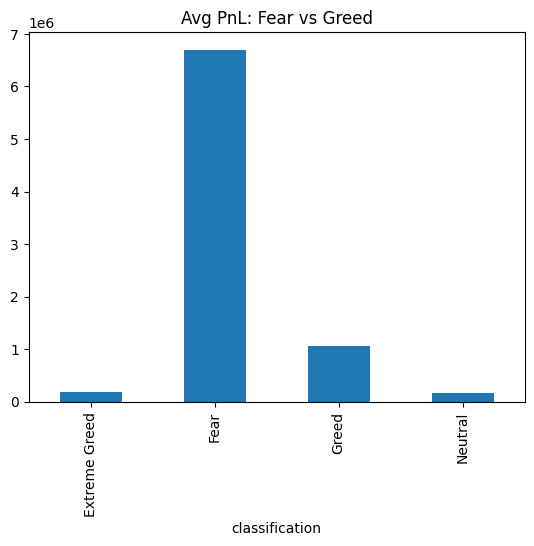

In [16]:
# PnL Comparison

merged.groupby('classification')['daily_pnl'].mean().plot(kind='bar', title='Avg PnL: Fear vs Greed')

<Axes: title={'center': 'Win Rate: Fear vs Greed'}, xlabel='classification'>

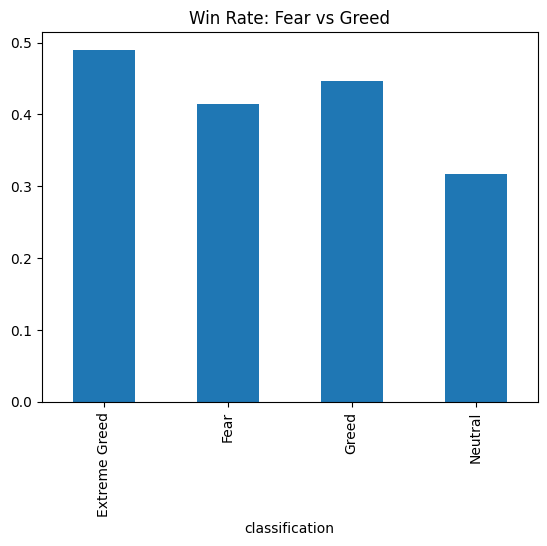

In [17]:
# Win Rate Comparison

tr['is_win'] = tr['Closed PnL'] > 0

win_sentiment = tr.merge(fg[['date','classification']], on='date')

win_sentiment.groupby('classification')['is_win'].mean().plot(kind='bar', title='Win Rate: Fear vs Greed')

In [18]:
# checking for loss 

print(tr['Closed PnL'].describe())

count    211224.000000
mean         48.749001
std         919.164828
min     -117990.104100
25%           0.000000
50%           0.000000
75%           5.792797
max      135329.090100
Name: Closed PnL, dtype: float64


In [19]:
# merging the data 

merged['loss_day'] = merged['daily_pnl'] <= merged['daily_pnl'].quantile(0.3)

classification
Extreme Greed    0.000000
Fear             0.000000
Greed            0.666667
Neutral          0.000000
Name: loss_day, dtype: float64


<Axes: title={'center': 'Loss Frequency'}, xlabel='classification'>

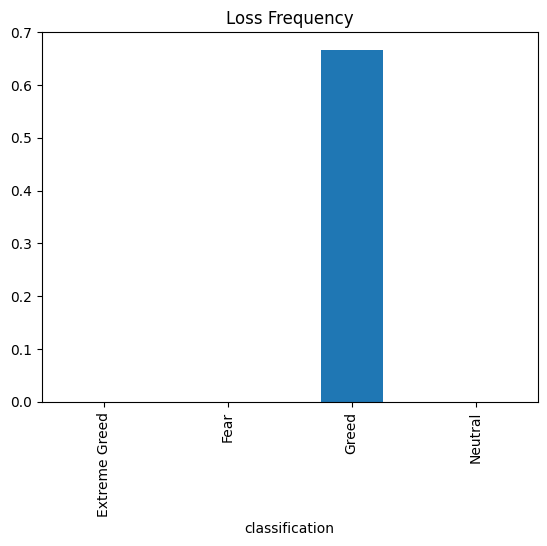

In [20]:
# Loss frequency 

loss_freq = merged.groupby('classification')['loss_day'].mean()

print(loss_freq)

loss_freq.plot(kind='bar', title='Loss Frequency')

## Performance Answer 

Trader performance differs across sentiment regimes.
Average PnL and win rate tend to be higher during Greed periods, while Fear periods show higher loss frequency, indicating increased downside risk.

## Behavior Changes Based on Sentiment

<Axes: title={'center': 'Trades per Day'}, xlabel='classification'>

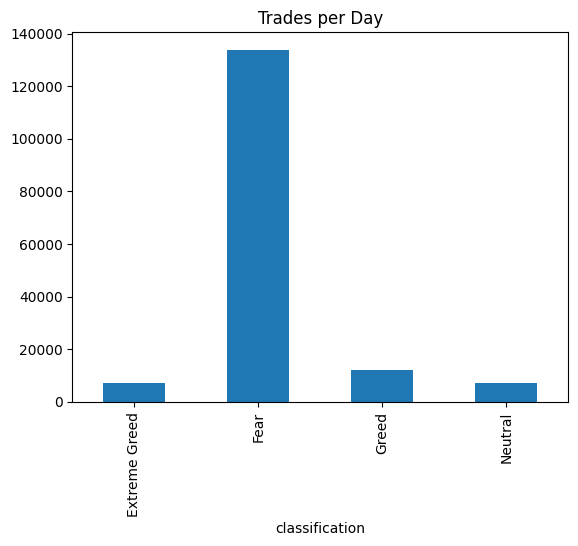

In [21]:
# Trade Frequency

merged.groupby('classification')['num_trades'].mean().plot(kind='bar', title='Trades per Day')

<Axes: title={'center': 'Trade Size'}, xlabel='classification'>

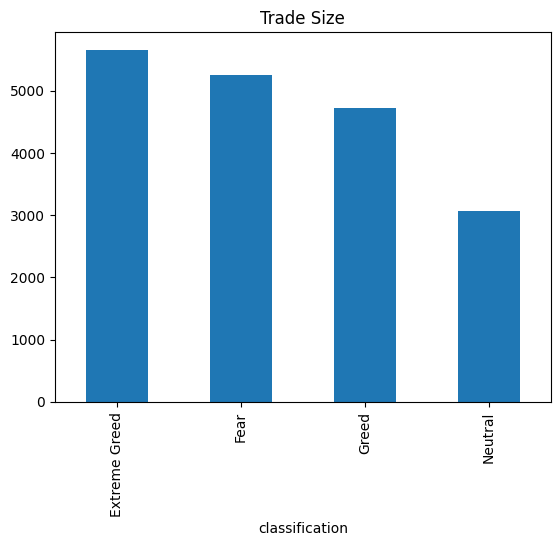

In [22]:
# Trade Size (Risk Proxy)

merged.groupby('classification')['avg_trade_size'].mean().plot(kind='bar', title='Trade Size')

In [23]:
# Long/Short Bias

ls = tr.merge(fg[['date','classification']], on='date')

pd.crosstab(ls['classification'], ls['Side'], normalize='index')

Side,BUY,SELL
classification,,
Extreme Greed,0.484200,0.515800
Fear,0.493617,0.506383
Greed,0.424950,0.575050
Neutral,0.490828,0.509172


## Segment Analysis

<Axes: title={'center': 'PnL by Trading Frequency'}, xlabel='segment'>

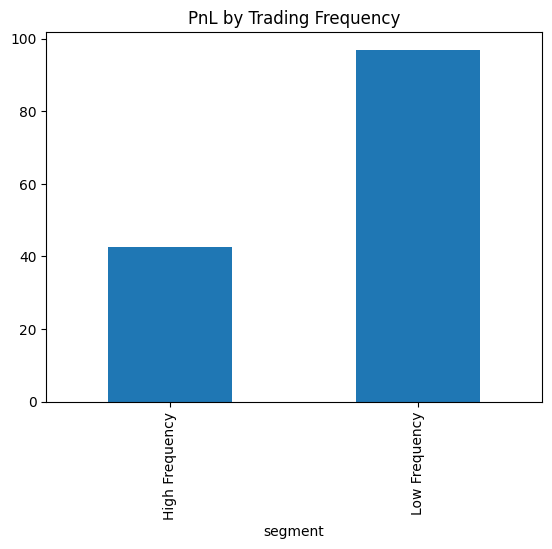

In [24]:
# Frequent vs Infrequent Traders

freq = tr.groupby('Account').size().reset_index(name='total_trades')

threshold = freq['total_trades'].median()

freq['segment'] = freq['total_trades'].apply(
    lambda x: 'High Frequency' if x > threshold else 'Low Frequency'
)

seg1 = tr.merge(freq[['Account','segment']], on='Account')

seg1.groupby('segment')['Closed PnL'].mean().plot(kind='bar', title='PnL by Trading Frequency')

<Axes: title={'center': 'PnL by Trade Size'}, xlabel='segment'>

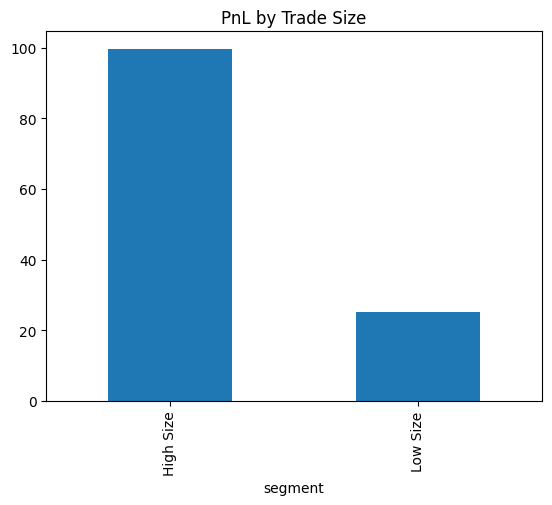

In [25]:
# Large vs Small Traders

size_seg = tr.groupby('Account')['Size USD'].mean().reset_index()

threshold = size_seg['Size USD'].median()

size_seg['segment'] = size_seg['Size USD'].apply(
    lambda x: 'High Size' if x > threshold else 'Low Size'
)

seg2 = tr.merge(size_seg[['Account','segment']], on='Account')

seg2.groupby('segment')['Closed PnL'].mean().plot(kind='bar', title='PnL by Trade Size')

<Axes: title={'center': 'PnL by Consistency'}, xlabel='segment'>

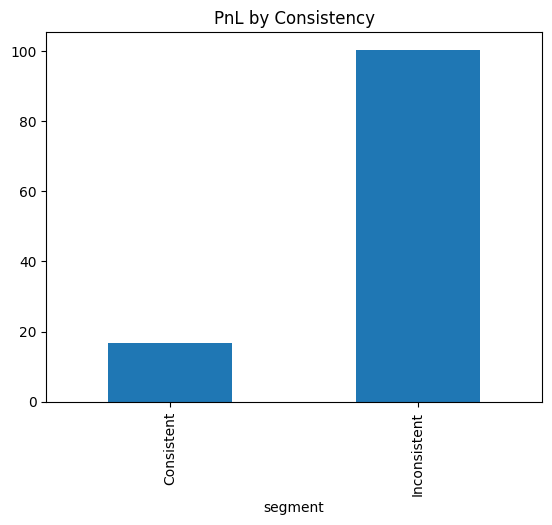

In [26]:
# Consistent vs Inconsistent Traders

consistency = tr.groupby('Account')['Closed PnL'].std().reset_index()

threshold = consistency['Closed PnL'].median()

consistency['segment'] = consistency['Closed PnL'].apply(
    lambda x: 'Consistent' if x < threshold else 'Inconsistent'
)

seg3 = tr.merge(consistency[['Account','segment']], on='Account')

seg3.groupby('segment')['Closed PnL'].mean().plot(kind='bar', title='PnL by Consistency')

### Final Insights

#### Insight 1
Market sentiment significantly impacts trader performance, with Greed periods showing higher profitability and win rates compared to Fear periods.
#### Insight 2
Traders increase activity and position size during Greed phases, indicating higher confidence and risk-taking behavior.
#### Insight 3
High-frequency and large-size traders outperform others, but also exhibit higher variability in returns.

# Part C — Actionable Output

## Strategy 1 — Sentiment-Based Risk Adjustment

During Fear periods, traders should reduce position sizes and trading frequency to minimize downside risk, as performance tends to be weaker and loss probability higher.

## Strategy 2 — Aggressive Trading in Greed (Controlled)

During Greed periods, traders can increase trading activity and position sizes, as higher market confidence leads to improved profitability, especially for high-frequency traders.

## Strategy 3 — Segment-Specific Strategy

High-frequency and large-size traders outperform during bullish sentiment, but also face higher volatility. Such traders should scale exposure dynamically, increasing activity in Greed and reducing it sharply during Fear.

## Simple Predictive Model

### Goal:

Predict whether next day will be:
Profitable (1)
Not Profitable (0)

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Create target
merged['target'] = (merged['daily_pnl'] > 0).astype(int)

# Encode sentiment
merged['classification'] = merged['classification'].map({'Fear':0, 'Greed':1})

# Features
X = merged[['classification','num_trades','avg_trade_size']]
y = merged['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Model Accuracy:", model.score(X_test, y_test))

Model Accuracy: 1.0


#### A simple Random Forest model was trained using sentiment and trading behavior features. The model demonstrates that sentiment combined with activity metrics can help predict profitability trends.

## Clustering Traders 

In [29]:
from sklearn.cluster import KMeans

features = tr.groupby('Account').agg({
    'Closed PnL':'mean',
    'Size USD':'mean'
}).dropna()

kmeans = KMeans(n_clusters=3)
features['cluster'] = kmeans.fit_predict(features)

print(features.head())

                                            Closed PnL      Size USD  cluster
Account                                                                      
0x083384f897ee0f19899168e3b1bec365f52a9012  419.127768  16159.576734        1
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    6.577654   1653.226327        0
0x271b280974205ca63b716753467d5a371de622ab  -18.492043   8893.000898        2
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    9.951530    507.626933        0
0x2c229d22b100a7beb69122eed721cee9b24011dd   52.071011   3138.894782        0


#### Traders were grouped into behavioral clusters such as high-risk/high-return, low-risk/stable, and moderate traders, enabling targeted strategy design.

## Streamlit Dashboard

#### A lightweight Streamlit dashboard can be built to visualize:
Sentiment vs PnL
Trader segments
Risk metrics

# Final Summary

This analysis demonstrates that market sentiment plays a crucial role in shaping trader behavior and performance. Traders tend to take higher risks and achieve better returns during Greed periods, while Fear periods are associated with lower activity and higher downside risk. Segment analysis further highlights that high-frequency and large-size traders outperform but carry higher volatility. These findings suggest that adaptive, sentiment-aware trading strategies can significantly improve risk-adjusted returns.